# RecSys МАГОЛЕГО, ФКН ВШЭ

## Домашняя работа 2 (Часть 1): Graph Laplacian

### Оценивание и штрафы
Всего заданий: **7**, максимальная оценка — **6 баллов (+1.5 бонус)**.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Весь код должен быть написан самостоятельно. Чужим кодом пользоваться запрещается,даже с указанием ссылки на источник. В разумных рамках, конечно. Взять пару очевидных строчек кода для реализации какого-то небольшого функционала можно.

Неэффективная реализация кода может негативно отразиться на оценке (например, лишние циклы, `np.vectorize`, `np.apply_along_axis` и так далее). Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных языковых моделей разрешено только в случае явного указания на это. Необходимо прописать (в соответствующих пунктах, где использовались, либо в начале/конце работы):

- какая языковая модель использовалась
- какие использовались промпты и в каких частях работы
- с какими сложностями вы столкнулись при использовании генеративных моделей, с чем они помогли больше всего
  
Copy-paste ответа генеративной модели запрещается (кроме графиков, но все равно нужно явно прописывать использование)

**Дедлайн: 15.03.2026 23:59 (по МСК)**

**Сдавать сюда: [Классрум](https://classroom.google.com/c/ODQzNjI1ODIzMDEy/a/ODQ2ODc0NzExMTI5/details)**

### О задании
В данном домашнем задании вы реализуете алгоритмы рекомендаций на Graph Laplacian для построения эмбеддингов и обучите supervised модель на датасете Yahoo! Movies.

P.S Пожалуйста, аккуратно оформляйте графики, ориентироваться можно на [это](https://github.com/esokolov/ml-course-hse/blob/master/2022-fall/seminars/sem02-charts.ipynb). У графиков обязательно должно быть:

- Название
- Подписанные оси
- Легенда, если необходимо (например, если несколько графиков на одном рисунке)
- Все должно быть четко видно и ничего не сливаться
- За некрасивые графики можем снизить баллы

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from scipy.sparse import csr_matrix, diags, identity, bmat
from scipy.sparse.linalg import eigsh
from collections import defaultdict

## Структура датасета

Датасет можете скачать по [ссылке](https://drive.google.com/file/d/1PsAL83MQnvQuTpjrNXs8CiPpOeSGcUL-/view?usp=share_link)

Датасет состоит из 6 основных файлов. Все данные представлены в текстовом формате, где колонки разделены символом табуляции `\t`.

### 1. Оценки пользователей
В этих файлах содержатся оценки фильмов пользователей
-  **Файлы:** `ydata-ymovies-user-movie-ratings-train-v1_0` и `ydata-ymovies-user-movie-ratings-test-v1_0`
- **Поля:**
  * User ID
  * Movie ID
  * Rating_13: от 1 (F) до 13 (A+)
  * Rating_5: упрощенная шкала от 1 до 5



### 2. Демография пользователей
Информация про аудиторию

- **Файл:** `ydata-ymovies-user-demographics-v1_0`
- **Поля:** 
  * User ID
  * Year of birth
  * Sex (`m`/`f`)

### 3. Описание фильмов
Метаданные фильмов
* **Файл:** `ydata-ymovies-movie-content-descr-v1_0`
* **Что внутри:** Название, синопсис, жанры, режиссеры, актеры, количество наград, средняя оценка критиков и даже ссылки на постеры.
* **Важно:** Если данных нет, стоит заглушка `\N`. Если в поле несколько значений (например, список актеров), они разделены символом `|`.

### 4. Списки соответствия 
Файлы `mapping-to-movielens` и `mapping-to-eachmovie` позволяют связать ID фильмов Yahoo с другими популярными датасетами (MovieLens и EachMovie). Это полезно, если вы хотите объединить данные из разных источников


### Graph Laplacian

В этой части мы будем использовать строить эмбеддинги пользователей и фильмов с помощью графа Лапласиана, чтобы потом на этих эмбеддингах обучать supervised модель, которая уже будет рекомендовать фильмы

**Задание 0 (1 балл):** Загрузите необходимые данные и постройте неориентированный невзвешенный двудольный граф. Ребро между пользователем $u$ и фильмом $i$ существует, если пользователь поставил фильму любую оценку. Сформируйте матрицу смежности $A$ (не забудьте использовать разреженные матрицы)

In [2]:
%%time
# 1) Загрузка
ratings_train = pd.read_csv(
    "data/ydata-ymovies-user-movie-ratings-train-v1_0.txt",
    sep="\t",
    header=None,
    names=["user_id", "movie_id", "rating_13", "rating_5"],
    dtype={"user_id": np.int32, "movie_id": np.int32, "rating_13": "string", "rating_5": np.int8},
    engine="python",
)

ratings_test = pd.read_csv(
    "data/ydata-ymovies-user-movie-ratings-test-v1_0.txt",
    sep="\t",
    header=None,
    names=["user_id", "movie_id", "rating_13", "rating_5"],
    dtype={"user_id": np.int32, "movie_id": np.int32, "rating_13": "string", "rating_5": np.int8},
    engine="python",
)

ratings_all = pd.concat([ratings_train[["user_id", "movie_id"]],
                         ratings_test[["user_id", "movie_id"]]],
                        ignore_index=True)

ratings_all = ratings_all.dropna()
ratings_all = ratings_all.drop_duplicates(subset=["user_id", "movie_id"])

user_ids = ratings_all["user_id"].unique()
movie_ids = ratings_all["movie_id"].unique()

user_ids = np.sort(user_ids)
movie_ids = np.sort(movie_ids)

user2idx = {u: i for i, u in enumerate(user_ids)}
movie2idx = {m: i for i, m in enumerate(movie_ids)}

U = len(user_ids)
M = len(movie_ids)

u_idx = ratings_all["user_id"].map(user2idx).to_numpy()
m_idx = ratings_all["movie_id"].map(movie2idx).to_numpy()

data = np.ones(len(ratings_all), dtype=np.uint8)
B = csr_matrix((data, (u_idx, m_idx)), shape=(U, M))

Zuu = csr_matrix((U, U), dtype=np.uint8)
Zmm = csr_matrix((M, M), dtype=np.uint8)

A = bmat([[Zuu, B],
          [B.T, Zmm]], format="csr", dtype=np.uint8)

print("Users:", U, "Movies:", M)
print("B shape:", B.shape, "nnz:", B.nnz)
print("A shape:", A.shape, "nnz:", A.nnz)

Users: 7642 Movies: 11916
B shape: (7642, 11916) nnz: 221364
A shape: (19558, 19558) nnz: 442728
CPU times: total: 922 ms
Wall time: 945 ms


**Задание 1 (1 балл):** На основе матрицы $A$ вычислите диагональную матрицу степеней $D$ и постройте нормализованный Лапласиан граф:

$$
L_{sym} = I - D^{-1/2} A D^{-1/2}
$$

Найдите $d$ (например, $d=64$) собственных вектора матрицы $L_{sym}$, соответствующих ее наименьшим собственным значениям. Не забудьте убрать самый первый вектор (почему?). Полученные вектора будем использовать в качестве признаков

In [3]:
def build_laplacian_sym(A: csr_matrix, eps: float = 1e-12):

    A = A.tocsr()

    deg = np.asarray(A.sum(axis=1)).ravel().astype(np.float64)

    inv_sqrt = np.zeros_like(deg)
    mask = deg > 0
    inv_sqrt[mask] = 1.0 / np.sqrt(deg[mask] + eps)

    D_inv_sqrt = diags(inv_sqrt, format="csr")

    N = A.shape[0]
    I = identity(N, format="csr", dtype=np.float64)

    A_norm = D_inv_sqrt @ A @ D_inv_sqrt
    L_sym = I - A_norm

    return L_sym, deg, D_inv_sqrt

### Почему мы отбрасываем первый вектор? Потому что он тривиальный. 
### Чтобы потом получить d признаков, считем d+1 векторов и отбрасываем первый, оставляя d.

In [4]:
def laplacian_embeddings(L_sym: csr_matrix, d: int = 64, seed: int = 42):

    evals, evecs = eigsh(L_sym, k=d+1, which="SM", tol=1e-4, maxiter=5_000)

    idx = np.argsort(evals)
    evals = evals[idx]
    evecs = evecs[:, idx]

    X = evecs[:, 1:d+1]

    return evals, evecs, X

In [5]:
L_sym, deg, D_inv_sqrt = build_laplacian_sym(A)

d = 64
evals, evecs, X = laplacian_embeddings(L_sym, d=d)

print("Smallest eigenvalues:", evals[:10])
print("Embeddings shape:", X.shape)  

Smallest eigenvalues: [4.44795093e-14 2.52868116e-02 3.19108705e-02 6.31185624e-02
 9.93745102e-02 1.15024200e-01 1.21763354e-01 1.40606601e-01
 1.43614243e-01 1.44882030e-01]
Embeddings shape: (19558, 64)


In [6]:
X_users = X[:U, :]      
X_movies = X[U:U+M, :]  

**Задание 2 (0.5 балла):** Модель должна понимать, какие фильмы релевантны, а какие нет. Поэтому необходимо также добавить к существующим тренировочным данным примеры нулевого класса (negative sampling)

Сгенерируйте негативные примеры (класс 0), случайно выбирая пары «пользователь-фильм», которых нет в тренировочных данных. Рекомендуемая пропорция негативных к позитивным примерам — 2:1 или 3:1

Создайте итоговую матрицу признаков $X$. Для каждой пары $(u,i)$ сформируйте вектор признаков, объединив эмбеддинг пользователя и эмбеддинг фильма (например, через конкатенацию). Вектор ответов y должен состоять из бинарных меток (1 и 0).

In [7]:
train_pairs = ratings_train[["user_id", "movie_id"]].drop_duplicates()

train_pairs["u_idx"] = train_pairs["user_id"].map(user2idx)
train_pairs["m_idx"] = train_pairs["movie_id"].map(movie2idx)

train_pairs = train_pairs.dropna()

pos_u = train_pairs["u_idx"].astype(int).to_numpy()
pos_m = train_pairs["m_idx"].astype(int).to_numpy()

n_pos = len(pos_u)

print("Positive samples:", n_pos)

Positive samples: 211231


In [8]:
positive_set = set(zip(pos_u, pos_m))

neg_ratio = 2 
n_neg = neg_ratio * n_pos

neg_u = []
neg_m = []

rng = np.random.default_rng(42)

while len(neg_u) < n_neg:
    
    u = rng.integers(0, X_users.shape[0])
    m = rng.integers(0, X_movies.shape[0])

    if (u, m) not in positive_set:
        neg_u.append(u)
        neg_m.append(m)

neg_u = np.array(neg_u)
neg_m = np.array(neg_m)

print("Negative samples:", len(neg_u))

Negative samples: 422462


In [9]:
X_pos = np.hstack([
    X_users[pos_u],
    X_movies[pos_m]
])

In [10]:
X_neg = np.hstack([
    X_users[neg_u],
    X_movies[neg_m]
])

In [11]:
X = np.vstack([X_pos, X_neg])

y = np.concatenate([
    np.ones(len(X_pos)),
    np.zeros(len(X_neg))
])

print("X shape:", X.shape)
print("y distribution:", np.bincount(y.astype(int)))

X shape: (633693, 128)
y distribution: [422462 211231]


In [12]:
perm = np.random.permutation(len(y))

X = X[perm]
y = y[perm]

**Задание 3 (1 балл):** Пришло время обучить модель на наших признаках:

- Выберите межу `RandomForestClassifier` и `GradientBoostingClassifier`
- Предсказывайте вероятность, что фильм понравится пользователю
- Провалидируйте вашу модель на тестовом датасете с метриками из ДЗ-1

### Сравнение скорости работы GradientBustingClassifier и RandomForestClassifier сделано в конце ноутбука. RandomForest обучается в 12 раз быстрее. Возьмем его в качестве классификатора.

### Берем заготовки из ДЗ-1

In [13]:
def precision_at_k(
    recommended_list: np.ndarray,
    relevant_items: np.ndarray,
    k: int = 10,
) -> float:
    if k == 0:
        return 0.0
        
    recommended_k = recommended_list[:k]
    relevant_set = set(relevant_items)
    
    hits = sum(1 for item in recommended_k if item in relevant_set)
    return hits / k


def recall_at_k(
    recommended_list: np.ndarray,
    relevant_items: np.ndarray,
    k: int = 10,
) -> float:
    recommended_k = recommended_list[:k]
    relevant_set = set(relevant_items)

    if len(relevant_set) == 0:
        return 0.0

    hits = sum(1 for item in recommended_k if item in relevant_set)
    return hits / len(relevant_set)

def ap_at_k(
    recommended_list: np.ndarray,
    relevant_items: np.ndarray,
    k: int = 10,
) -> float:
    recommended_k = recommended_list[:k]
    relevant_set = set(relevant_items)

    if len(relevant_set) == 0:
        return 0.0

    score = 0.0
    hits = 0

    for i, item in enumerate(recommended_k, start=1):
        if item in relevant_set:
            hits += 1
            score += hits / i 

    return score / min(k, len(relevant_set))

def ndcg_at_k(
    recommended_list: np.ndarray,
    relevant_items: np.ndarray,
    k: int = 10,
) -> float:
    recommended_k = recommended_list[:k]
    relevant_set = set(relevant_items)

    dcg = 0.0
    for i, item in enumerate(recommended_k, start=1):
        rel_i = 1 if item in relevant_set else 0
        if rel_i:
            dcg += 1 / np.log2(i + 1)

    ideal_hits = min(k, len(relevant_set))
    if ideal_hits == 0:
        return 0.0

    idcg = sum(1 / np.log2(i + 1) for i in range(1, ideal_hits + 1))

    return dcg / idcg

def evaluate_model(model, ks=(1, 5, 10, 20, 35, 50)):
    results = {k: [] for k in ks}

    for user in users:
        model._current_user_id = user 
    
        seen = train_user_items.get(user, np.array([]))
        relevant = test_user_items.get(user, np.array([]))


        if len(relevant) == 0:
            continue

        for k in ks:
            recs = model.predict(seen, k)
            metrics = evaluate_recommender(recs, relevant, k)
            results[k].append(metrics)

    avg = {}
    for k in ks:
        avg[k] = {
            m: np.mean([r[m] for r in results[k]])
            for m in ["precision@k", "recall@k", "ap@k", "ndcg@k"]
        }

    return avg

def evaluate_recommender(
    recommended_list: np.ndarray,
    relevant_items: np.ndarray,
    k: int = 10,
) -> dict:
    return {
        "precision@k": precision_at_k(recommended_list, relevant_items, k),
        "recall@k": recall_at_k(recommended_list, relevant_items, k),
        "ap@k": ap_at_k(recommended_list, relevant_items, k),
        "ndcg@k": ndcg_at_k(recommended_list, relevant_items, k),
    }

def plot_scores(scores, title):
    ks = sorted(scores.keys())
    metrics = ["precision@k", "recall@k", "ap@k", "ndcg@k"]

    plt.figure()
    for m in metrics:
        values = [scores[k][m] for k in ks]
        plt.plot(ks, values, marker="o", label=m)

    plt.xticks(ks)
    
    plt.xlabel("K")
    plt.ylabel("Score")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

In [14]:
train_user_items = defaultdict(list)
test_user_items = defaultdict(list)

for _, row in ratings_train.iterrows():
    if row.user_id in user2idx and row.movie_id in movie2idx:
        u = user2idx[row.user_id]
        m = movie2idx[row.movie_id]
        train_user_items[u].append(m)

for _, row in ratings_test.iterrows():
    if row.user_id in user2idx and row.movie_id in movie2idx:
        u = user2idx[row.user_id]
        m = movie2idx[row.movie_id]
        test_user_items[u].append(m)

train_user_items = {u: np.array(v) for u, v in train_user_items.items()}
test_user_items = {u: np.array(v) for u, v in test_user_items.items()}

users = list(test_user_items.keys())

In [15]:
%%time
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

model.fit(X, y)

CPU times: user 32min 39s, sys: 14.2 s, total: 32min 54s
Wall time: 4min 36s


,n_estimators,150
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Класс-обертка для использования моих заготовок из ДЗ-1

In [15]:
class LaplacianRecommender:

    def __init__(self, clf, X_users, X_movies):
        self.clf = clf
        self.X_users = X_users
        self.X_movies = X_movies

    def predict(self, seen_items, k=10):
        """
        seen_items — фильмы пользователя из train
        """
        user = self._current_user_id

        user_emb = self.X_users[user]

        n_movies = self.X_movies.shape[0]

        movie_ids = np.arange(n_movies)

        mask = np.ones(n_movies, dtype=bool)
        mask[seen_items] = False

        candidates = movie_ids[mask]

        user_block = np.repeat(
            user_emb.reshape(1, -1),
            len(candidates),
            axis=0
        )

        movie_block = self.X_movies[candidates]

        X_pred = np.hstack([user_block, movie_block])
        X_pred = np.nan_to_num(X_pred)

        probs = self.clf.predict_proba(X_pred)[:, 1]

        top_idx = np.argsort(-probs)[:k]

        return candidates[top_idx]

In [ ]:
recommender = LaplacianRecommender(model, X_users, X_movies)

In [18]:
%%time
scores = evaluate_model(recommender)

CPU times: user 1h 5min 56s, sys: 2min 24s, total: 1h 8min 20s
Wall time: 21min 34s


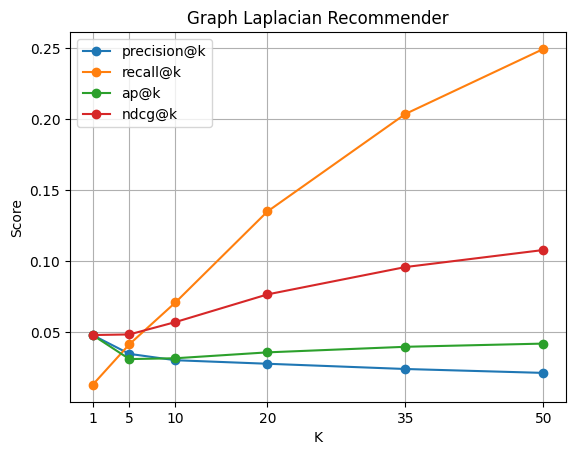

In [19]:
plot_scores(scores, "Graph Laplacian Recommender")

### Эмбеддинги, полученные с помощью графа Лапласиана, отражают совместную структуру взаимодействий пользователей и фильмов.

### precision@k плавно снижается, так как чем длиннее список рекомендаций, тем меньше точность на каждую отдельную позицию.

### recall@k уверенно растёт, так как модель находит всё больше релевантных фильмов по мере расширения списка рекомендаций.

### ap@k стабильна и немного растёт. Это значит, что ранжирование в целом не разваливается и релевантные элементы остаются достаточно высоко в списке.

### ndcg@k монотонно растёт, то есть релевантные фильмы не просто попадают в топ, а попадают туда в относительно правильном порядке.

**Задание 4 (1 балл):** Добавьте к вашим графовым признакам метаданные из файлов `ydata-ymovies-user-demographics` и `ydata-ymovies-movie-content-descr`. Замерьте, насколько изменились метрики после обогащения модели этими признаками

In [17]:
users_meta = pd.read_csv(
    "data/ydata-ymovies-user-demographics-v1_0.txt",
    sep="\t",
    header=None,
    names=["user_id", "birth_year", "sex"]
)


In [18]:
users_meta.head()

,user_id,birth_year,sex
0,1,1979,f
1,2,1987,m
2,3,1988,f
3,4,1983,m
4,5,1988,m


In [20]:
users_meta["birth_year"] = pd.to_numeric(
    users_meta["birth_year"],
    errors="coerce"
)

users_meta["age"] = 2005 - users_meta["birth_year"]
users_meta["age"] = users_meta["age"].fillna(
    users_meta["age"].median()
).round().astype(int)

users_meta["sex"] = (users_meta["sex"] == "m").astype(int)

user_features = users_meta.set_index("user_id")[["age", "sex"]]

In [21]:
movies_meta = pd.read_csv(
    "data/ydata-ymovies-movie-content-descr-v1_0.txt",
    sep="\t",
    header=None,
    na_values="\\N",
    encoding="latin-1",
    low_memory=False
)

In [60]:
movie_id_col = 0
content_rating_col = 4
genres_col = 10

movies_meta_feat = movies_meta.copy()

if movies_meta_feat.index.name != movie_id_col:
    movies_meta_feat = movies_meta_feat.set_index(movie_id_col)


content_rating = (
    movies_meta_feat[content_rating_col]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .str.replace(";", "", regex=False)
)

content_rating = content_rating.replace({
    "No Rating": "Unrated",
    "unrated": "Unrated",
    "Not Yet Rated": "Unrated"
})

content_rating = content_rating.str.split().str[0]

rating_dummies = pd.get_dummies(
    content_rating,
    prefix="rating"
)

genres = (
    movies_meta_feat[genres_col]
    .fillna("")
    .astype(str)
    .str.strip()
)

genre_dummies = genres.str.get_dummies(sep="|")

if "~Delete" in genre_dummies.columns:
    genre_dummies = genre_dummies.drop(columns=["~Delete"])

movie_features = pd.concat(
    [rating_dummies, genre_dummies],
    axis=1
)

movie_features = movie_features.loc[
    movie_features.index.intersection(movie2idx.keys())
]

movie_features = movie_features.sort_index()


In [61]:
user_meta_matrix = np.zeros((len(user2idx), user_features.shape[1]))

for uid, idx in user2idx.items():
    if uid in user_features.index:
        user_meta_matrix[idx] = user_features.loc[uid].values

movie_meta_matrix = np.zeros((len(movie2idx), movie_features.shape[1]))

for mid, idx in movie2idx.items():
    if mid in movie_features.index:
        movie_meta_matrix[idx] = movie_features.loc[mid].values

In [62]:
X_pos = np.hstack([
    X_users[pos_u],
    X_movies[pos_m],
    user_meta_matrix[pos_u],
    movie_meta_matrix[pos_m],
])

X_neg = np.hstack([
    X_users[neg_u],
    X_movies[neg_m],
    user_meta_matrix[neg_u],
    movie_meta_matrix[neg_m],
])

X_new = np.vstack([X_pos, X_neg])
y_new = np.concatenate([
    np.ones(len(X_pos)),
    np.zeros(len(X_neg))
])

perm = np.random.permutation(len(y_new))
X_new = X_new[perm]
y_new = y_new[perm]

In [63]:
%%time
model_meta = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

model_meta.fit(X_new, y_new)

CPU times: total: 37min 16s
Wall time: 10min 11s


,n_estimators,150
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [64]:
class LaplacianRecommender:

    def __init__(
        self,
        clf,
        X_users,
        X_movies,
        user_meta,
        movie_meta
    ):
        self.clf = clf
        self.X_users = X_users
        self.X_movies = X_movies
        self.user_meta = user_meta
        self.movie_meta = movie_meta

    def predict(self, seen_items, k=10):

        user = self._current_user_id

        user_emb = self.X_users[user]
        user_meta = self.user_meta[user]

        n_movies = self.X_movies.shape[0]
        movie_ids = np.arange(n_movies)

        mask = np.ones(n_movies, dtype=bool)
        mask[seen_items] = False

        candidates = movie_ids[mask]

        user_block = np.repeat(
            user_emb.reshape(1, -1),
            len(candidates),
            axis=0
        )

        user_meta_block = np.repeat(
            user_meta.reshape(1, -1),
            len(candidates),
            axis=0
        )

        movie_block = self.X_movies[candidates]
        movie_meta_block = self.movie_meta[candidates]

        X_pred = np.hstack([
            user_block,
            movie_block,
            user_meta_block,
            movie_meta_block
        ])
        X_pred = np.nan_to_num(X_pred)

        probs = self.clf.predict_proba(X_pred)[:, 1]

        top_idx = np.argsort(-probs)[:k]

        return candidates[top_idx]

In [65]:
recommender_meta = LaplacianRecommender(
    model_meta,
    X_users,
    X_movies,
    user_meta_matrix,
    movie_meta_matrix
)

In [66]:
scores_meta = evaluate_model(recommender_meta)

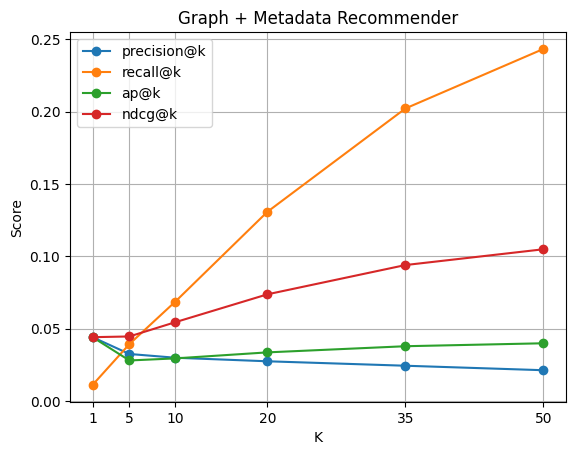

In [67]:
plot_scores(scores_meta, "Graph + Metadata Recommender")

### Модель перестаёт рекомендовать только "самые безопасные" фильмы, начинает покрывать больше интересов пользователя. Графовая модель ловила фильмы, просмотренные людьми с похожими предпочтениями. Метаданные добавили к этому фильмы схожие по содержанию и просмотренные пользователями схожими по полу, возрасту. 

### После добавления метаданных пользователей и фильмов форма метрик осталась практически такой же, как у базовой модели на графовых эмбеддингах. recall@k, ap@k и ndcg@k изменились незначительно, а явного улучшения качества рекомендаций не произошло. Это показывает, что основной вклад в качество модели вносит collaborative signal из графа взаимодействий, а простые контентные и демографические признаки в данной постановке дают лишь ограниченную дополнительную информацию. 

**Задание 5:** Давайте сделаем нашу модель более продвинутой и точной. Для этого вам предстоит реализовать следующие улучшения:

**1. Взвешенный граф взаимодействий (0.5 балла)**

Сейчас мы рассматриваем только сам факт взаимодействия (оценил / не оценил). Однако значения оценок несут в себе много полезной информации!

Вместо единиц в матрице смежности $A$ используйте нормализованные значения из колонки с рейтингами

**2. Сэмплинг «сложных» негативных примеров (Hard Negative Sampling) (0.5 балла)**

Генерация случайных негативных примеров (Uniform Negative Sampling) — это хороший старт. Но случайный несмотренный фильм может оказаться никому не известным артхаусом, и модели будет слишком легко отличить его от популярных просмотренных блокбастеров

Реализуйте сэмплинг сложных негативных примеров. Например, предлагайте в качестве нулей фильмы, которые очень популярны во всем датасете, но данный конкретный пользователь их так и не посмотрел

**3. Эксперименты с объединением эмбеддингов (0.5 балла)**

То, как именно мы объединяем эмбеддинг пользователя $E_u$ и фильма $E_i$, критически влияет на качество обучения модели

Сравните разные способы формирования итогового вектора признаков для пары $(u, i)$:
  - Конкатенация: $[E_u, E_i]$
  - Поэлементное умножение (Hadamard product): $E_u \odot E_i$
  - Косинусная близость: Скалярное произведение нормализованных векторов

На каждый пункт дайте ответ, как изменились метрики рекомендаций / качество собственных векторов? Без анализа баллы не засчитаются!

In [68]:
def build_weighted_A_from_ratings_train(scheme="01"):

    df = ratings_train[["user_id", "movie_id", "rating_5"]].dropna().copy()
    df["u"] = df["user_id"].map(user2idx)
    df["m"] = df["movie_id"].map(movie2idx)
    df = df.dropna()

    u = df["u"].astype(int).to_numpy()
    m = df["m"].astype(int).to_numpy()
    r = df["rating_5"].astype(float).to_numpy()

    if scheme == "01":
        w = r / 5.0
    elif scheme == "centered01":
        w = (r - 3.0) / 2.0      
        w = (w + 1.0) / 2.0     
    else:
        raise ValueError("scheme must be '01' or 'centered01'")

    B = csr_matrix((w, (u, m)), shape=(U, M))
    B.sum_duplicates()

    Zuu = csr_matrix((U, U), dtype=np.float64)
    Zmm = csr_matrix((M, M), dtype=np.float64)
    A = bmat([[Zuu, B], [B.T, Zmm]], format="csr", dtype=np.float64)
    return A

In [69]:
def compute_weighted_embeddings(d=64, scheme="01"):
    A_w = build_weighted_A_from_ratings_train(scheme=scheme)
    L_sym_w, _, _ = build_laplacian_sym(A_w)
    _, _, X_w = laplacian_embeddings(L_sym_w, d=d)

    X_users_w = X_w[:U]
    X_movies_w = X_w[U:U+M]
    return X_users_w, X_movies_w

In [70]:
def get_positive_pairs_from_train():
    df = ratings_train[["user_id", "movie_id"]].drop_duplicates().copy()
    df["u"] = df["user_id"].map(user2idx)
    df["m"] = df["movie_id"].map(movie2idx)
    df = df.dropna()
    pos_u = df["u"].astype(int).to_numpy()
    pos_m = df["m"].astype(int).to_numpy()
    return pos_u, pos_m

In [71]:
def build_popular_pool(top_pop=2000):
    pop_raw = ratings_train.groupby("movie_id").size().sort_values(ascending=False)
    popular_idx = []
    for mid in pop_raw.index.values:
        if mid in movie2idx:
            popular_idx.append(movie2idx[mid])
        if len(popular_idx) >= top_pop:
            break
    return np.array(popular_idx, dtype=int)

In [72]:
def hard_negative_sampling(pos_u, pos_m, neg_ratio=2, top_pop=2000, hard_frac=1.0, seed=42):
   
    rng = np.random.default_rng(seed)
    positive_set = set(zip(pos_u.tolist(), pos_m.tolist()))

    n_pos = len(pos_u)
    n_neg = neg_ratio * n_pos
    n_hard = int(n_neg * hard_frac)

    popular_pool = build_popular_pool(top_pop=top_pop)

    neg_u = np.empty(n_neg, dtype=np.int32)
    neg_m = np.empty(n_neg, dtype=np.int32)

    filled = 0
    for idx in rng.permutation(n_pos):
        if filled >= n_hard:
            break
        u = int(pos_u[idx])
        seen = set(train_user_items.get(u, np.array([], dtype=int)).tolist())

        for _ in range(50):
            m = int(rng.choice(popular_pool))
            if (m not in seen) and ((u, m) not in positive_set):
                neg_u[filled] = u
                neg_m[filled] = m
                filled += 1
                break
    i = filled
    while i < n_neg:
        u = int(rng.integers(0, U))
        m = int(rng.integers(0, M))
        if (u, m) not in positive_set:
            neg_u[i] = u
            neg_m[i] = m
            i += 1

    return neg_u, neg_m


In [73]:
def pair_features(Eu, Ei, mode="concat"):

    if mode == "concat":
        return np.hstack([Eu, Ei])

    if mode == "hadamard":
        return np.hstack([Eu, Ei, Eu * Ei])

    if mode == "cosine":
        u_norm = np.linalg.norm(Eu, axis=1, keepdims=True) + 1e-12
        i_norm = np.linalg.norm(Ei, axis=1, keepdims=True) + 1e-12
        cos = np.sum(Eu * Ei, axis=1, keepdims=True) / (u_norm * i_norm)
        return np.hstack([Eu, Ei, cos])

    raise ValueError("mode must be concat|hadamard|cosine")

In [74]:
def build_train_xy(X_users, X_movies, pos_u, pos_m, neg_u, neg_m, mode="concat", seed=42):
    X_pos = pair_features(X_users[pos_u], X_movies[pos_m], mode=mode)
    X_neg = pair_features(X_users[neg_u], X_movies[neg_m], mode=mode)

    X = np.vstack([X_pos, X_neg])
    y = np.concatenate([np.ones(len(X_pos)), np.zeros(len(X_neg))])

    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(y))
    return X[perm], y[perm]

In [75]:
class AdvancedRecommender:

    def __init__(self, clf, X_users, X_movies, mode="concat", candidate_size=None, seed=42):
        self.clf = clf
        self.X_users = X_users
        self.X_movies = X_movies
        self.mode = mode
        self.candidate_size = candidate_size
        self.rng = np.random.default_rng(seed)

    def predict(self, seen_items, k=10):
        u = self._current_user_id
        user_emb = self.X_users[u]

        all_movies = np.arange(M)
        mask = np.ones(M, dtype=bool)
        mask[seen_items] = False
        candidates = all_movies[mask]

        if self.candidate_size is not None and len(candidates) > self.candidate_size:
            candidates = self.rng.choice(candidates, size=self.candidate_size, replace=False)

        Eu = np.repeat(user_emb.reshape(1, -1), len(candidates), axis=0)
        Ei = self.X_movies[candidates]
        X_pred = pair_features(Eu, Ei, mode=self.mode)
        X_pred = np.nan_to_num(X_pred)

        probs = self.clf.predict_proba(X_pred)[:, 1]
        top_idx = np.argsort(-probs)[:k]
        return candidates[top_idx]

In [76]:
def run_task5(
    d=64,
    graph_scheme="01",
    neg_ratio=2,
    top_pop=2000,
    hard_frac=1.0,
    modes=("concat", "hadamard", "cosine"),
    candidate_size=None,
):
    X_users_w, X_movies_w = compute_weighted_embeddings(d=d, scheme=graph_scheme)

    pos_u, pos_m = get_positive_pairs_from_train()
    neg_u, neg_m = hard_negative_sampling(
        pos_u, pos_m,
        neg_ratio=neg_ratio,
        top_pop=top_pop,
        hard_frac=hard_frac,
        seed=42
    )

    results = {}

    for mode in modes:
        X_train, y_train = build_train_xy(
            X_users_w, X_movies_w,
            pos_u, pos_m,
            neg_u, neg_m,
            mode=mode,
            seed=42
        )

        X_train = np.nan_to_num(X_train)

        clf = RandomForestClassifier(
            n_estimators=150,
            max_depth=20,
            max_features="sqrt",
            n_jobs=-1,
            random_state=42
        )
        clf.fit(X_train, y_train)

        rec = AdvancedRecommender(
            clf=clf,
            X_users=X_users_w,
            X_movies=X_movies_w,
            mode=mode,
            candidate_size=candidate_size
        )

        scores = evaluate_model(rec)
        results[mode] = scores
        plot_scores(scores, f"Task 5 — weighted graph + hard neg, mode={mode}")

    return results


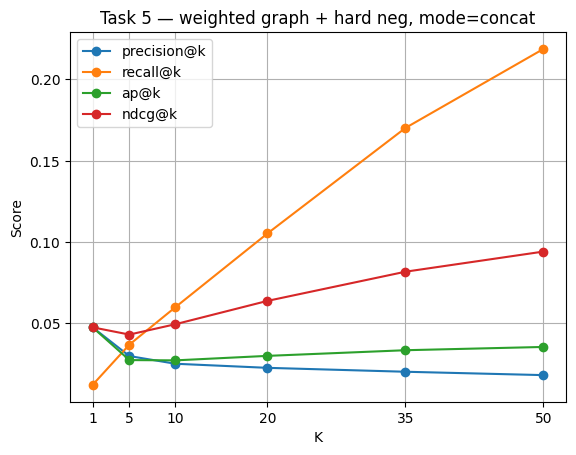

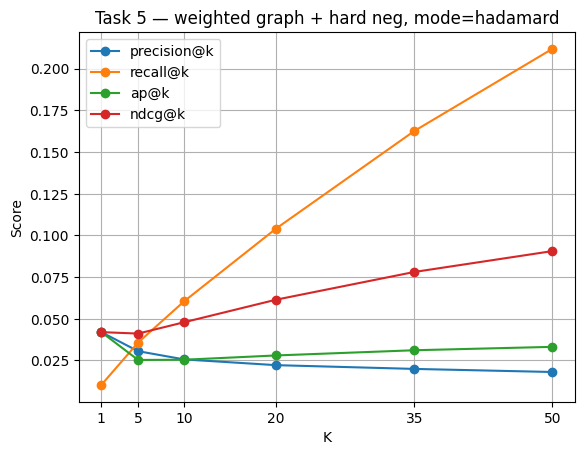

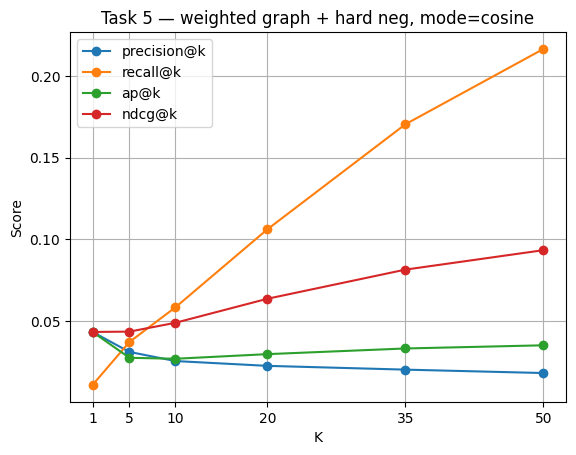

CPU times: total: 5h 29min 7s
Wall time: 1h 57min 46s


In [79]:
%%time
results_task5 = run_task5(
    d=64,
    graph_scheme="01",    
    neg_ratio=2,
    top_pop=2000,
    hard_frac=1.0,        
    modes=("concat","hadamard","cosine"),
    candidate_size=None   
)

### Все три варианта ведут себя стабильно и ожидаемо. Ранжирование остаётся осмысленным.
### weighted graph + hard negatives делает модель более содержательной:
### - weighted graph учитывает не только факт оценки, но и её величину,
### - hard negatives делают обучение реалистичнее,

### Лучшим вариантом оказался concat.

### Но по итоговым offline-метрикам baseline пока оказался лучше.

### В baseline негативы были проще, а здесь модель учится отличать пользователя не от случайных фильмов, а от популярных, но невыбранных. Это делает задачу ближе к реальности, но метрики могут просесть.

## Возможно у нас произошли более глубокие изменения. Посмотрим на спектр лапласиана.

In [80]:
A_w = build_weighted_A_from_ratings_train(scheme="01")
X_users_w, X_movies_w = compute_weighted_embeddings(d=64, scheme="01")
L_sym_w, _, _ = build_laplacian_sym(A_w)
evals_w, evecs_w, X_w = laplacian_embeddings(L_sym_w, d=64)

print("Baseline smallest eigenvalues:", evals[:10])
print("Weighted smallest eigenvalues:", evals_w[:10])

def cosine_sim(a, b):
    return np.sum(a * b, axis=1) / (
        np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1) + 1e-9
    )

df_eval = ratings_train[["user_id", "movie_id", "rating_5"]].copy()
df_eval["u"] = df_eval["user_id"].map(user2idx)
df_eval["m"] = df_eval["movie_id"].map(movie2idx)
df_eval = df_eval.dropna()

u_idx = df_eval["u"].astype(int).to_numpy()
m_idx = df_eval["m"].astype(int).to_numpy()

df_eval["cos_base"] = cosine_sim(X_users[u_idx], X_movies[m_idx])
df_eval["cos_weighted"] = cosine_sim(X_users_w[u_idx], X_movies_w[m_idx])

print(df_eval.groupby("rating_5")[["cos_base", "cos_weighted"]].mean())

Baseline smallest eigenvalues: [4.44795093e-14 2.52868116e-02 3.19108705e-02 6.31185624e-02
 9.93745102e-02 1.15024200e-01 1.21763354e-01 1.40606601e-01
 1.43614243e-01 1.44882030e-01]
Weighted smallest eigenvalues: [5.66827357e-14 1.87019051e-02 2.33678093e-02 6.38896358e-02
 8.19384722e-02 8.71297254e-02 1.09461635e-01 1.13206432e-01
 1.33021714e-01 1.33662046e-01]
          cos_base  cos_weighted
rating_5                        
1         0.647155      0.589046
2         0.667339      0.642268
3         0.690258      0.679970
4         0.675195      0.677030
5         0.608038      0.623783


### Для оценки изменения собственных векторов была сравнена спектральная структура бинарного и взвешенного графов. После перехода к взвешенному графу первые ненулевые собственные значения изменились, что говорит о перестройке геометрии графа и, соответственно, спектральных эмбеддингов.
### Дополнительно сравнение cosine similarity для пар *(user, movie)* показало, что в weighted-пространстве низкие оценки в среднем соответствуют меньшему сходству, а высокие - немного большему. Это подтверждает, что использование оценок от 1 до 5 меняет структуру embedding space по сравнению с бинарной моделью.

**Бонусное задание 1 (1.5 балла):** Представьте, что появился новый пользователь или в каталог добавили премьеру фильма. Поскольку их не было в обучающих данных, у них нет связей в графе, а значит, мы не можем вычислить для них векторы Лапласа

Как сделать для них качественные рекомендации, опираясь только на файлы `ydata-ymovies-user-demographics` и `ydata-ymovies-movie-content-descr`? Предложите 1-2 способа и проверьте их на тестовой выборке.

### Это настоящий cold-start: графовые эмбеддинги здесь не помогут, потому что у нового пользователя и/или нового фильма нет рёбер в графе. Значит, нужно строить рекомендации только по metadata.

### *Способ 1.* Демографический popularity baseline для нового пользователя: на основании возраста и пола можно рекомендовать фильмы, которые подходят похожему демографическому сегменту.

In [84]:
users_meta = pd.read_csv(
    "data/ydata-ymovies-user-demographics-v1_0.txt",
    sep="\t",
    header=None,
    names=["user_id", "birth_year", "sex"]
)

users_meta["birth_year"] = pd.to_numeric(users_meta["birth_year"], errors="coerce")
users_meta["age"] = 2005 - users_meta["birth_year"]
users_meta["age"] = users_meta["age"].fillna(users_meta["age"].median()).round().astype(int)
users_meta["sex"] = users_meta["sex"].astype(str).str.lower()

users_meta["age_bucket"] = pd.cut(
    users_meta["age"],
    bins=[0, 18, 25, 35, 45, 60, 100],
    labels=["<18", "18-25", "25-35", "35-45", "45-60", "60+"]
)

users_meta["segment"] = users_meta["sex"] + "_" + users_meta["age_bucket"].astype(str)
users_meta.head()

,user_id,birth_year,sex,age,age_bucket,segment
0,1,1979.0,f,26,25-35,f_25-35
1,2,1987.0,m,18,<18,m_<18
2,3,1988.0,f,17,<18,f_<18
3,4,1983.0,m,22,18-25,m_18-25
4,5,1988.0,m,17,<18,m_<18


In [85]:
train_seg = ratings_train.merge(
    users_meta[["user_id", "segment"]],
    on="user_id",
    how="left"
)

train_seg["liked"] = (train_seg["rating_5"] >= 4).astype(int)

segment_movie_scores = (
    train_seg.groupby(["segment", "movie_id"])["liked"]
    .mean()
    .reset_index(name="segment_score")
)

global_movie_scores = (
    train_seg.groupby("movie_id")["liked"]
    .mean()
    .reset_index(name="global_score")
)

In [86]:
def recommend_new_user_by_segment(user_id, k=10):
    row = users_meta.loc[users_meta["user_id"] == user_id]
    if len(row) == 0:
        recs = global_movie_scores.sort_values("global_score", ascending=False)
        return recs["movie_id"].head(k).to_numpy()

    segment = row["segment"].iloc[0]

    seg_scores = segment_movie_scores.loc[
        segment_movie_scores["segment"] == segment,
        ["movie_id", "segment_score"]
    ]

    if len(seg_scores) == 0:
        recs = global_movie_scores.sort_values("global_score", ascending=False)
        return recs["movie_id"].head(k).to_numpy()

    recs = seg_scores.merge(global_movie_scores, on="movie_id", how="left")
    recs["final_score"] = 0.8 * recs["segment_score"] + 0.2 * recs["global_score"].fillna(0)

    recs = recs.sort_values("final_score", ascending=False)
    return recs["movie_id"].head(k).to_numpy()

Для new user cold-start честная проверка такая:
- игнорируем train-историю пользователя полностью
- используем только его demographics
- сравниваем рекомендации с его фильмами из test

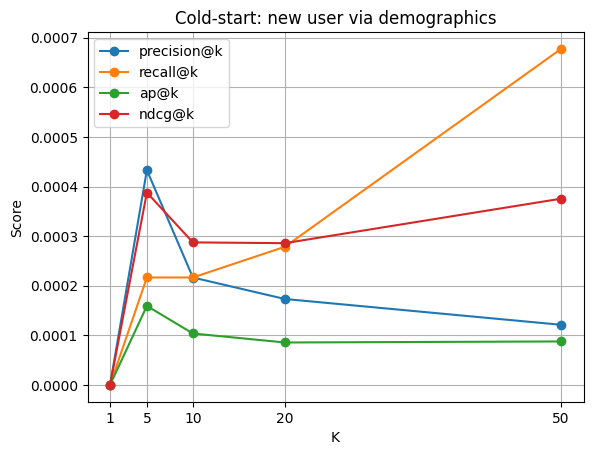

In [87]:
test_user_items_raw = (
    ratings_test.groupby("user_id")["movie_id"]
    .apply(lambda x: np.array(list(set(x))))
    .to_dict()
)

def evaluate_new_user_segment_model(ks=(1, 5, 10, 20, 50)):
    results = {k: [] for k in ks}

    for user_id, relevant in test_user_items_raw.items():
        if len(relevant) == 0:
            continue

        recs = recommend_new_user_by_segment(user_id, k=max(ks))

        for k in ks:
            metrics = evaluate_recommender(recs, relevant, k)
            results[k].append(metrics)

    avg = {}
    for k in ks:
        avg[k] = {
            m: np.mean([r[m] for r in results[k]])
            for m in ["precision@k", "recall@k", "ap@k", "ndcg@k"]
        }
    return avg

scores_new_user_segment = evaluate_new_user_segment_model()
plot_scores(scores_new_user_segment, "Cold-start: new user via demographics")

### Рекомендации для нового пользователя только по демографическим признакам (пол и возрастная группа) показали крайне низкое качество: все ranking-метрики оказались близки к нулю. Это означает, что такие признаки слишком грубы и не позволяют надёжно восстанавливать индивидуальные предпочтения пользователя. 

### *Способ 2.* Добавим признаки фильма

### Строим модель, которая смотрит только на:
### - признаки пользователя (age, sex)
### - признаки фильма (genres, content rating)
### и учится предсказывать, понравится ли фильм пользователю.

### Такая модель сможет работать как для нового пользователя (если есть demographics), так и для нового фильма (если есть content metadata)

In [88]:
movies_meta = pd.read_csv(
    "data/ydata-ymovies-movie-content-descr-v1_0.txt",
    sep="\t",
    header=None,
    na_values="\\N",
    encoding="latin-1",
    low_memory=False
)

movie_id_col = 0
content_rating_col = 4
genres_col = 10

movies_meta_feat = movies_meta.copy()

if movies_meta_feat.index.name != movie_id_col:
    movies_meta_feat = movies_meta_feat.set_index(movie_id_col)

content_rating = (
    movies_meta_feat[content_rating_col]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .str.replace(";", "", regex=False)
)

content_rating = content_rating.replace({
    "No Rating": "Unrated",
    "unrated": "Unrated",
    "Not Yet Rated": "Unrated"
})

content_rating = content_rating.str.split().str[0]

rating_dummies = pd.get_dummies(content_rating, prefix="rating")

genres = (
    movies_meta_feat[genres_col]
    .fillna("")
    .astype(str)
    .str.strip()
)

genre_dummies = genres.str.get_dummies(sep="|")

if "~Delete" in genre_dummies.columns:
    genre_dummies = genre_dummies.drop(columns=["~Delete"])

movie_features = pd.concat([rating_dummies, genre_dummies], axis=1).fillna(0)

Строим train-выборку из metadata.
Позитивы: реальные пары из ratings_train
Негативы: случайные пары user–movie, которых нет в train

In [89]:
train_pairs = ratings_train[["user_id", "movie_id", "rating_5"]].drop_duplicates().copy()
train_pairs["label"] = (train_pairs["rating_5"] >= 4).astype(int)

positive_pairs = train_pairs.loc[train_pairs["label"] == 1, ["user_id", "movie_id"]].copy()

positive_set = set(zip(
    ratings_train["user_id"].to_numpy(),
    ratings_train["movie_id"].to_numpy()
))

rng = np.random.default_rng(42)
all_users = train_pairs["user_id"].unique()
all_movies = train_pairs["movie_id"].unique()

neg_samples = []
while len(neg_samples) < 2 * len(positive_pairs):
    u = rng.choice(all_users)
    m = rng.choice(all_movies)
    if (u, m) not in positive_set:
        neg_samples.append((u, m))

negative_pairs = pd.DataFrame(neg_samples, columns=["user_id", "movie_id"])
negative_pairs["label"] = 0

train_meta_pairs = pd.concat([
    positive_pairs.assign(label=1),
    negative_pairs
], ignore_index=True)

In [90]:
def build_meta_pair_matrix(df_pairs):
    df = df_pairs.copy()

    df = df.merge(user_features, left_on="user_id", right_index=True, how="left")
    df = df.merge(movie_features, left_on="movie_id", right_index=True, how="left")

    df = df.fillna(0)

    X = df.drop(columns=["user_id", "movie_id", "label"]).to_numpy()
    y = df["label"].to_numpy()

    return X, y

X_meta, y_meta = build_meta_pair_matrix(train_meta_pairs)

In [91]:
meta_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

meta_model.fit(X_meta, y_meta)

,n_estimators,150
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Для нового поЬльзователя у нас нет истории, но есть demographics. Значит, для каждого фильма строим пару: (user_meta, movie_meta) и ранжируем по predict_proba.

### Для оценки cold-start модели ранжирование выполнялось не по всему каталогу, а по ограниченному пулу наиболее популярных фильмов из train. Такой подход снижает вычислительную стоимость и одновременно соответствует реальному сценарию рекомендаций для нового пользователя, когда система сначала предлагает наиболее релевантные фильмы из ограниченного candidate pool.

In [99]:
popular_movies = (
    ratings_train.groupby("movie_id")
    .size()
    .sort_values(ascending=False)
    .head(1000)
    .index
)

popular_movies = [m for m in popular_movies if m in movie_features.index]

In [95]:
def recommend_new_user_meta_model_fast(user_id, k=10, candidate_movies=None):
    if candidate_movies is None:
        candidate_movies = movie_features.index

    candidate_movies = [m for m in candidate_movies if m in movie_features.index]

    if user_id not in user_features.index:
        return np.array(candidate_movies[:k])

    user_row = user_features.loc[[user_id]]
    movies_idx = pd.Index(candidate_movies)

    user_block = pd.concat([user_row] * len(movies_idx), ignore_index=True)
    movie_block = movie_features.loc[movies_idx].reset_index(drop=True)

    X_pred = pd.concat(
        [user_block.reset_index(drop=True), movie_block],
        axis=1
    ).fillna(0).to_numpy()

    probs = meta_model.predict_proba(X_pred)[:, 1]

    recs = pd.DataFrame({
        "movie_id": movies_idx,
        "score": probs
    }).sort_values("score", ascending=False)

    return recs["movie_id"].head(k).to_numpy()

In [96]:
def evaluate_new_user_meta_model_fast(ks=(1, 5, 10, 20, 50), candidate_movies=None):
    if candidate_movies is None:
        candidate_movies = popular_movies

    results = {k: [] for k in ks}

    for user_id, relevant in test_user_items_raw.items():
        if len(relevant) == 0:
            continue

        recs = recommend_new_user_meta_model_fast(
            user_id=user_id,
            k=max(ks),
            candidate_movies=candidate_movies
        )

        for k in ks:
            metrics = evaluate_recommender(recs, relevant, k)
            results[k].append(metrics)

    avg = {}
    for k in ks:
        avg[k] = {
            m: np.mean([r[m] for r in results[k]])
            for m in ["precision@k", "recall@k", "ap@k", "ndcg@k"]
        }

    return avg

In [ ]:
%%time
scores_new_user_meta_fast = evaluate_new_user_meta_model_fast(
    ks=(1, 5, 10, 20, 50),
    candidate_movies=popular_movies
)

plot_scores(scores_new_user_meta_fast, "Cold-start: metadata-only model (fast)")

### Для cold-start сценария были проверены два подхода.
### Первый, основанный только на демографической популярности фильмов внутри возрастно-половых сегментов, показал крайне низкое качество и практически не даёт полезных рекомендаций.
### Второй подход модель, использующая признаки пользователя и фильма, оказался значительно лучше: все ranking-метрики выросли на порядки. Это показывает, что даже без графа можно строить осмысленные рекомендации, если учитывать содержательные признаки фильмов, однако качество таких рекомендаций всё равно заметно уступает основной графовой модели.

## Conclusion

Опишите выводы ваших экспериментов:


### В работе была реализована рекомендательная система на основе графа взаимодействий пользователей и фильмов. Сначала был построен двудольный граф user–movie и на его основе вычислены спектральные эмбеддинги с помощью нормализованного лапласиана. Полученные векторы использовались как признаки для supervised-модели, которая ранжировала фильмы для пользователей.

### Базовая модель на графовых эмбеддингах показала устойчивое и осмысленное поведение: при увеличении длины списка рекомендаций росли recall@k и ndcg@k, а precision@k плавно снижалась, что соответствует ожидаемому компромиссу между полнотой и точностью. Это подтверждает, что спектральные эмбеддинги действительно отражают структуру взаимодействий пользователей и фильмов.

### Далее модель была расширена метаданными пользователей и фильмов. Метаданные не привели к заметному улучшению качества по сравнению с графовым baseline, так как основные метрики остались на близком уровне. Это показывает, что в данном датасете основной сигнал для рекомендаций даёт именно структура взаимодействий, а простые демографические и контентные признаки играют вспомогательную роль.

### Была исследована модель на взвешенном графе, где вместо бинарного факта взаимодействия использовались оценки от 1 до 5, а также применялся hard negative sampling. Переход к взвешенному графу изменил спектр лапласиана и, следовательно, структуру собственных векторов. Эмбеддинги стали описывать уже не просто наличие связи, а более детализированную геометрию взаимодействий. Однако по итоговым ranking-метрикам эта версия не превзошла baseline. Вероятно, это связано с тем, что hard negative sampling делает задачу обучения более сложной и приближенной к реальности, а изменение структуры графа не обязательно сразу даёт рост offline-метрик.

### Среди способов объединения эмбеддингов лучшим оказался вариант с конкатенацией. Варианты с Hadamard product и cosine similarity показали немного более слабые результаты. Это означает, что в данной задаче наиболее полезно сохранять полный набор признаков пользователя и фильма, а не сжимать их взаимодействие в более узкую форму.

### Также был рассмотрен cold-start сценарий. Для новых пользователей и новых фильмов графовые эмбеддинги недоступны, поэтому были протестированы два подхода, основанные только на metadata. Демографический baseline, использующий возраст и пол, показал почти нулевое качество. Значительно лучше сработала модель, использующая признаки пользователя и фильма. Она дала осмысленные рекомендации, хотя и заметно уступила основной графовой системе. Это подтверждает, что для cold-start одних демографических признаков недостаточно, а содержательные признаки фильмов существенно важнее.

### Итоговый практический вывод состоит в том, что лучшей моделью в рамках экспериментов оказался базовый graph-based recommender с supervised ранжированием, а для cold-start наиболее разумным дополнением является модель, использующая признаки и пользователя, и фильма.

### P.S. Сравнение скорости работы GradientBustingClassifier и RandomForestClassifier

In [100]:
import time

X_users_w, X_movies_w = compute_weighted_embeddings(d=64, scheme="01")

pos_u, pos_m = get_positive_pairs_from_train()

neg_u, neg_m = hard_negative_sampling(
    pos_u, pos_m,
    neg_ratio=2,
    top_pop=2000,
    hard_frac=1.0,
    seed=42
)

X_train, y_train = build_train_xy(
    X_users_w, X_movies_w,
    pos_u, pos_m,
    neg_u, neg_m,
    mode="concat",
    seed=42
)

X_train = np.nan_to_num(X_train)

idx = np.random.choice(len(y_train), size=100_000, replace=False)
X_small = X_train[idx]
y_small = y_train[idx]

t0 = time.time()
gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    random_state=42
)
gb.fit(X_small, y_small)
t_gb = time.time() - t0

t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)
rf.fit(X_small, y_small)
t_rf = time.time()-t0

print("GB:", round(t_rf, 2), "sec")
print("GB :", round(t_gb, 2), "sec")
print("GB / RF ratio:", round(t_gb / t_rf, 2))

GB: 54.65 sec
GB : 455.38 sec
GB / RF ratio: 8.33
